# Search for Supermassive Binary Black Holes Systems: A brief presentation of the new methodology

## Introduction

This work is based on <a href="#ref1">[1]</a> as part of my bachelor's thesis. In that work, singular spectrum analysis (SSA) is employed for the first time on data from the Fermi-LAT Space Telescope to study periodicities on the light curves of several blazars. The aim of using SSA is to isolate the periodic behaviour of the emissions from long-term trends and noise, and then compute the Lomb-Scargle periodogram (LSP) on the isolated oscillatory component to determine the most significant periods.
As a result, 46 blazars are identified as potential candidates for quasi-periodic oscillations (QPOs), which provides a foundation for future investigations on the detection of binary supermas
sive black hole (SMBHs) systems.

Here, some alternatives are presented to try to get more evidence on the previous results. Blazar PG1553+113 will be used as sample since it is the same one used on <a href="#ref1">[1]</a>. The first task is importing the functions we will be using and getting the light curve (LC) data. 

In [2]:
import pandas as pd
import numpy as np
from ftperiodogram.modeler import FastTemplatePeriodogram, FastMultiTemplatePeriodogram, TemplateModel
from ftperiodogram.template import Template
import matplotlib.pyplot as plt
from blazar_tools import GetLCRData, plot_analysis, time_splits, plot_split_pgram, SSA, SSA_pyts, mjd_to_year, year_to_mjd, Periodogram
from blazar_tools import LC_sim, features_extraction

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve,roc_auc_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
path = '../data/enlacesCurvas.txt'
blazar = 'PG1553+113'
LCR_data = GetLCRData(path)
df_data= LCR_data.df_dict[blazar]
df_data.head()

,t_met,flux,flux_error,t_mjd,t_year
0,240883201.0,7.220000e-08,6.800000e-09,54698.000012,2008.635181
1,243475201.0,5.090000e-08,6.500000e-09,54728.000012,2008.717317
2,248659201.0,6.970000e-08,7.500000e-09,54788.000012,2008.881588
3,251251201.0,6.180000e-08,6.200000e-09,54818.000012,2008.963724
4,253843201.0,4.160000e-08,5.800000e-09,54848.000012,2009.045859


# 1. Current methodology

### Singular spectrum analysis

The SSA is a powerful technique for time series analysis with multiple applications in mathematics, physics or economics. The method consists in two main stages: decomposition of the series into its components, and reconstruction to separate long term trends and noise from the oscillatory components. 

We have implemented an algorithm to do that for us. In the decompostion stage of the signal, the only parameter we need to set is the window lenght $L$, which is an integer such that $2 \leq L \leq N/2$, being $N$ the number of components of the time series. This parameter sets how the time series is embeded into a multidimensional series with vectors of lenght $L$. If the time series contains a periodic component with an integer period it is recommended to set the window length proportional to that period. A window lenght fullfiling these conditions that works well is $L = 0.4 N$.

The decomposition is performed as follows:

In [3]:
flux = df_data.flux.values
t_mjd = df_data.t_mjd.values

n = len(flux)
L = int(0.4 * n) # L must be an integer

ssa = SSA(t_mjd, flux, L)

The next step is reconstruction. After the decompostion, we can asses the quality of the separation of signal and noise components by observing the correlations among the different components. SSA presents the components sorting them by importance. This importance is measured from their eigenvalues during the decomposition process. Therefore, we will have a look to the first 10 more important components and their correlations. 

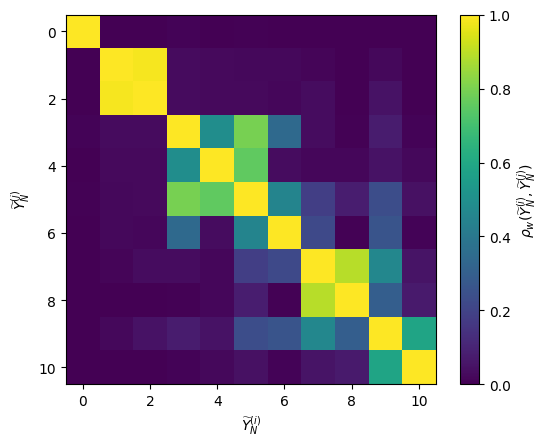

In [4]:
ssa.plot_wcorr(max = 10)

TThe correlation is measured from 0 to 1, being 1 the self correlation, and therefore a value present in the diagonal. As a first approximation, there is a clear division between three groups: 
- Component 0, which is the slowest varying component. This will be the trend.
- Components 1 and 2, which are the next most significant group of components. These will form the oscillatory component.
- The rest of the components are less important and will be treated as noise. 

Following this pipeline, an automatic reconstruction algorithm is defined which groups the most correlated components from the begining as the oscillatory component, then groups all the previous components as trend, an the rest as noise. 

In [5]:
df_ssa = ssa.auto_reconstruction()
df_ssa.head()

,trend,oscillatory,noise
54698.000012,4.214135e-08,8.285486e-09,2.158517e-08
54728.000012,4.213093e-08,7.067962e-09,1.811277e-09
54788.000012,4.212857e-08,5.503058e-09,2.207450e-08
54818.000012,4.207720e-08,3.395256e-09,1.627658e-08
54848.000012,4.201517e-08,1.143689e-09,-1.537870e-09


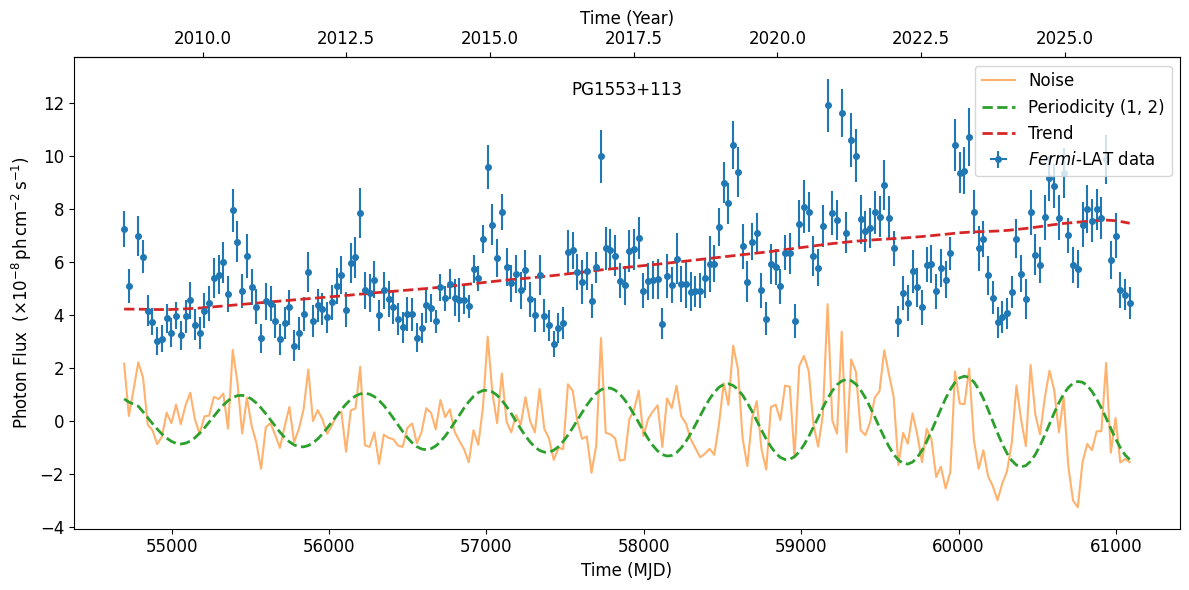

In [6]:
plot_analysis(df_data, df_ssa, blazar)

###  Lomb-Scargle periodogram

LSP is based on perfmoring a least sequare fitting of sinusoidal function to a given data. The power of each period is related to how good the fit is using a sinusoidal function of that frequency. The result is the so called periodogram, which represents the power of each fitted period. 
The detected period will be taken as the period corresponding to the peak of the periodogram and its uncertainty will be the FWHM of the gaussian function that best fits the peak. The LSP is performed for the oscillatory component only.

Full LSP Period detected: 2.08 +- 0.22 yr


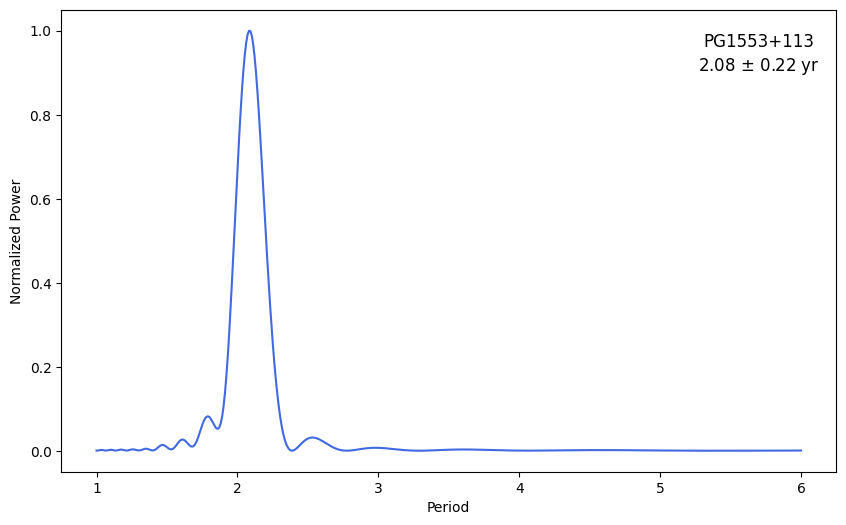

In [7]:
per = Periodogram(df_ssa, blazar)
pgram_dict = per.LSP()

## 2. New approach for periodicity detection

### 2.1 Obervational sample and methodology

To accurately resolve high-frequency intra-cycle variations and improve temporal resolution, we utilized 7-day binned light curves (LCs) instead of the standard 30-day bins. We excluded any LCs containing more than 30% upper limits, as these low-significance detections are unsuitable for our analysis. Out of more than 5,500 blazars listed in the 4FGL catalog, exactly 100 candidates met these criteria and were selected for further study.

### Fast Template Periodogram: a first aplication in the search of blazar's periodicities

As explaine before, to computation of the LSP is based on fitting a sinusoidal function. The advantange of FTP is that this method allows any other pre defined function as a template. Since PG 1553+113 is a very good sample of regular oscillations, we can define a sample from this LC and try to fit it to other blazars. If the behaviour is the same, the attempt to fit this template will be succesful. In order to dude that, we apply a method called epoch folding. 

This technique consists of partitioning the time series into segments of a trial period $P$ and "folding" them into a single cycle. By binning these phases and calculating the average flux in each bin, we suppress stochastic noise and non-periodic fluctuations. The resulting folded light curve provides a high-signal-to-noise "archetype" or template that captures the underlying physical morphology of the oscillation, which in the case of blazars often deviates from a simple sinusoid due to the complex dynamics of relativistic jets.

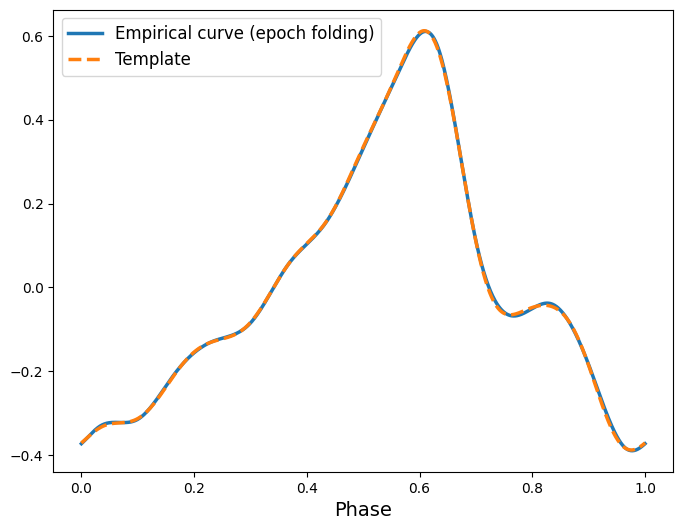

In [21]:
# Empirical epoch folded template shape
forma_template = np.loadtxt('.\data\PG1553_template_shape.csv', delimiter = ',')

nharmonics = 8

x = np.linspace(0, 1, 1000)
template_empirical = Template.from_sampled(forma_template, nharmonics= nharmonics, template_id = 'Empirical PG 1553')
template_plot = template_empirical(x) / (np.max(template_empirical(x)) - np.min(template_empirical(x)))

plt.figure(figsize = (8, 6))
plt.plot(x, forma_template, lw = 2.5, label = 'Empirical curve (epoch folding)')
plt.plot(x, template_plot, linestyle = '--', lw=2.5,  label = f'Template')
plt.xlabel('Phase', fontsize = 14)
plt.legend(fontsize = 12)
plt.show()

Another great hypotesis for QPOs is periodic flares. A mathematical way of modelling flares is by a gaussian peak. In this work, we try with different peak widths by using three values for $\sigma$.

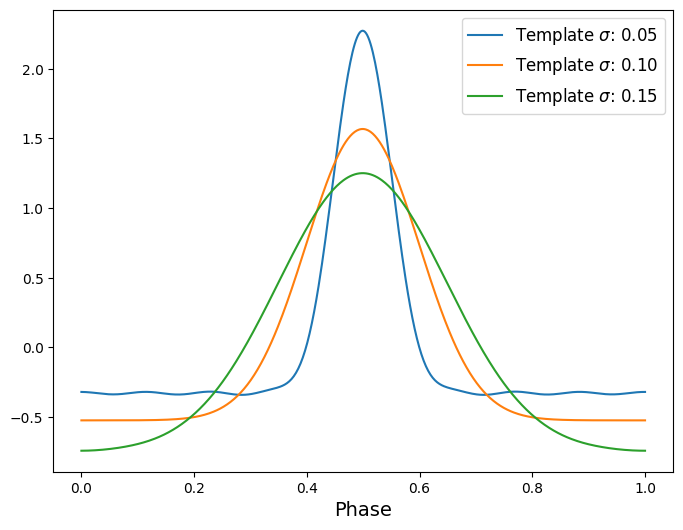

In [24]:
# Gaussian peak templates
def gauss_template(sigma_template, x):
            return (1 / (sigma_template * np.sqrt(2 * np.pi)))*np.exp(-(x-0.5)**2 / (2*sigma_template**2) )
                
x = np.linspace(0, 1, 500)
templates_gauss = []

plt.figure(figsize = (8, 6))
for i in range(3):
    sigma_template = 0.05 + 0.05*i
    y = (gauss_template(sigma_template, x) )
    y = (y - np.mean(y)) / np.std(y)
    
    nharmonics = 8
    template_id = f'{sigma_template:.2f}'
    template = Template.from_sampled(y, nharmonics = nharmonics, template_id = template_id)
    templates_gauss.append(template)
    
    plt.plot(x, template(x), label = f'Template $\sigma$: {sigma_template:.2f}')
plt.xlabel('Phase', fontsize = 14)
plt.legend(fontsize = 12)
plt.show()

### SSA for detrending

As previously discussed, Singular Spectrum Analysis (SSA) is a powerful tool for identifying smooth periodic components. However, by selecting only the first oscillatory component, we risk losing information from higher-frequency elements and, consequently, identifying false periodicities. Following this refined approach, we will apply SSA exclusively to extract the slowly varying trend component, which will then be subtracted from the raw signal.

To identify this trend, we analyze the periods of the first 11 Reconstructed Components (RCs). If a component's period exceeds six years, it is categorized as part of the trend and removed from the signal. This process results in a detrended signal with regular amplitude, centered around its mean, which preserves all relevant oscillatory information for subsequent FTP computation.

It is important to note that LCR Light Curves (LCs) contain low-significance detections, referred to as upper limits. Since these bins are not suitable for our analysis, they are excluded. To preserve the continuity required for Singular Spectrum Analysis (SSA), the gaps left by these upper limits are linearly interpolated. Once the trend is identified and removed from the signal, these gaps are reintroduced to replicate the original data structure, ensuring an accurate and consistent FTP analysis.

### 2.2 Analysis on the selected sample

To evaluate the light curves across different phenomenological regimes, we employed three distinct template families. First, a Sinusoidal Template was used as a baseline to represent smooth geometric variations, such as idealized Doppler boosting. Second, a Gaussian Template with a fixed fractional width ($\sigma = 0.05$) was adopted to target localized flares and discrete emission events; broader Gaussians were excluded to avoid morphological degeneracy with the sinusoidal model and to optimize the statistical penalty of multiple-trials corrections. Finally, the empirical template based on PG 1553+113 was utilized as an observational reference. This multi-template approach ensures sensitivity to both continuous harmonic waves and short-lived macroscopic flaring timescales resolved by our 7-day binning.

The periodogram power peak identifies the frequency that most closely matches the observed data. To evaluate the statistical significance of each fit and account for stochastic variability, we calibrated the False Alarm Probability (FAP) using $10^4$ Monte Carlo simulations for each blazar, assuming a power-law noise spectrum ($P(\nu) \propto \nu^{-\alpha}$) based on the best-fit spectral index of the raw light curves. To ensure the synthetic data accurately mirrored observational biases and our analysis pipeline, each simulated curve was resampled to the exact 7-day observing cadence, artificially masked with identical observational gaps, and subjected to the same SSA detrending procedure prior to FTP evaluation. From these simulations, we computed the Cumulative Distribution Function (CDF) of the peaks to determine the FAP for each template. Finally, since three distinct template morphologies were tested independently for each light curve, a Šidák multiple-trials correction was applied to derive the source-specific global significance. Using the global FAP, we can compute the global significan of each detection. 

In [27]:
fap_results = pd.read_csv('data/FAP_results.csv').set_index('blazar')
fap_results.head()

,FAP_sin_local,FAP_sin_global,sigma_sin,FAP_emp_local,FAP_emp_global,sigma_emp,FAP_gauss_local,FAP_gauss_global,sigma_gauss,mode_sigma_temp
blazar,,,,,,,,,,
J0102.8+5824,0.045,0.205641,0.821640,0.001,0.004990,2.576521,0.001,0.004990,2.576521,0.05
J0050.7-0929,0.555,0.982550,-2.109512,0.706,0.997803,-2.848466,0.672,0.996204,-2.669663,0.05
J0108.6+0134,0.326,0.860909,-1.084412,0.253,0.767404,-0.730323,0.148,0.551050,-0.128315,0.10
J0112.1+2245,0.051,0.230283,0.737915,0.067,0.293018,0.544589,0.049,0.222138,0.764993,0.05
J0120.4-2701,0.016,0.077481,1.422224,0.012,0.058577,1.566830,0.090,0.375968,0.316088,0.05


At this stage, we are able to classify which blazars are most likely to exhibit a Quasi-Periodic Oscillation (QPO) based on their statistical significance. Furthermore, the primary advantage of this multi-template approach is the ability to assess which specific template provides the best fit for each source. By identifying the preferred morphology, we can better characterize the underlying physical processes driving the periodicity in different blazar classes. Nevertheless, we must consider the possibility that these periodicities are merely the result of stochastic flares that have become coincidentally aligned. To address this, we will employ Machine Learning (ML) techniques to rigorously distinguish between true periodicity and underlying red noise processes. By training our models on both synthetic periodic signals and stochastic simulations, we can more effectively validate the physical nature of the detected QPOs.

## 3. Machine Learning applied to periodicity detection

Blazar emission is dominated by red noise. This noise is characterized by random emission that translates into random peaks in the periodogram. In <a href="#ref1">[1]</a>, the significance is the parameter used to confirm whether the detected period was artificially created by stochastic noise or by a real physical oscillation. A low statistical significance indicates that a periodogram peak may be the result of stochastic noise rather than a physical process; therefore, robust periodicities must exhibit high significance levels to be considered credible. However, even significant peaks can arise from stochastic flares that have become coincidentally aligned, mimicking a periodic signal. To address this, we developed a Machine Learning (ML) model trained on a large library of simulated light curves. This training set includes both purely stochastic signals and those embedding synthetic periodic components, enabling the model to effectively distinguish between true physical oscillations and noise-driven artifacts.

### Random forest as model

A Random Forest is based on multiple decision trees, which are among the most powerful machine learning algorithms available today. They can be used for both classification and regression tasks. Decision trees are a type of supervised learning method consisting of a root node, branches, internal nodes, and leaf nodes. Based on the available features, an evaluation is conducted at every node to split the data into subsets until the leaf nodes are reached. These leaf nodes represent all possible outcomes within the dataset. The performance of a decision tree is determined by how the available features are used when splitting a node. 


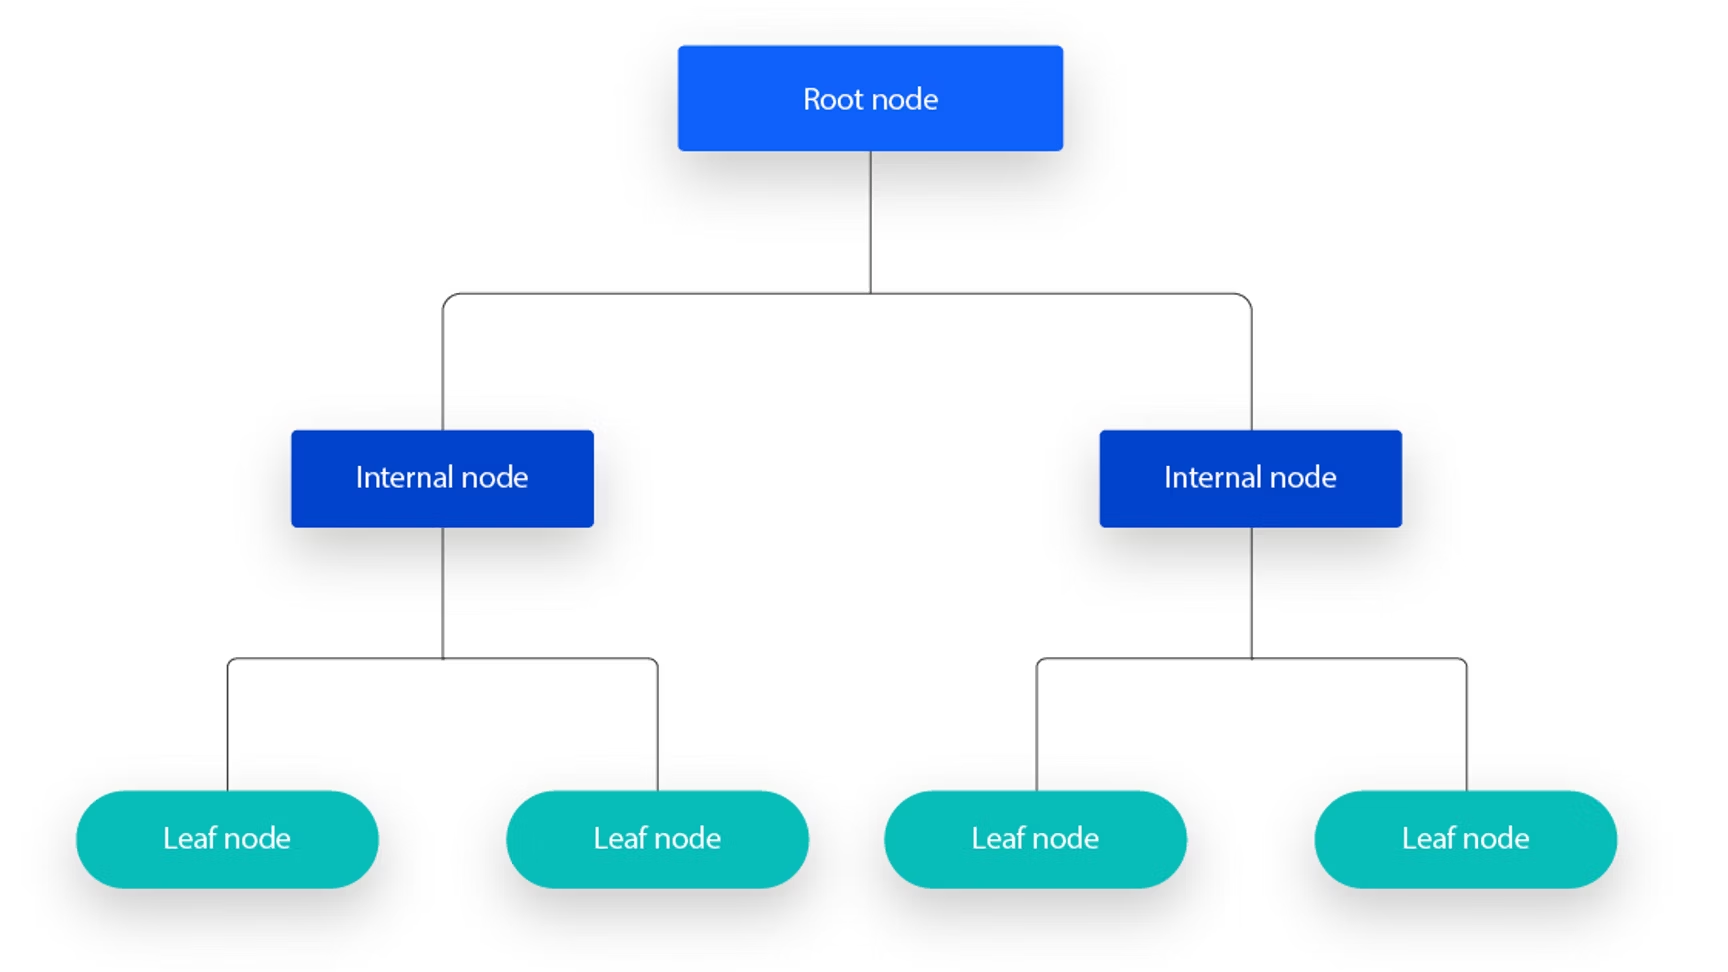

The random forest is an ensemble of the best decision trees, each one of them using a different subset of the features. This results in a greater tree diversity and richer overall choices. Finally, the decission of the forest is based on majority voting among all of the available trees. If most of the trees determine that the signal contains a periodic component, this will give the predicition of the forest. This vote counting gives the probability of a prediction. 

The main parameters we can control for a random forest are:
- The number of trees
- The maximum depth of each tree
- The maximum number of features to consider when looking for the best split

The RandomForestClassifier was configured to achieve a robust classification by optimizing the trade-off between model complexity and generalization. For this specific task, we utilized 100 estimators (trees) to ensure a stable consensus without excessive computational overhead. To prevent the model from over-fitting to the high-cadence noise in the simulated light curves, we constrained the maximum depth to 15 and required a minimum of 5 samples per leaf, which acts as a smoothing constraint on the decision boundaries.

The parameter n_jobs=-1 was employed to leverage all available processors for parallel computation, while random_state=42 ensures the reproducibility of our results. Notably, since the training set is composed of distinct classes (stochastic vs. periodic), we applied a 'balanced' class weight to adjust the importance of each sample, ensuring that the classifier remains sensitive to both populations regardless of any potential imbalance in the synthetic universe.

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1, class_weight='balanced')

### LC simulation and feature selection

To train the classifier, we generated a synthetic dataset of $5 \times 10^4$ simulated light curves, split equally between purely stochastic red noise and genuine periodic signals. The noise-only sample utilized power-law indices drawn from our empirical Fermi-LAT distribution, while the periodic sample incorporated various injected morphologies—including sinusoidal, Gaussian, and empirical shapes—across a wide range of amplitudes and periods. Crucially, all simulations were masked with the exact observational gaps of our 100 Fermi-LAT targets to accurately replicate instrumental degradation and ensure the model is robust against real-world sampling biases.

[]

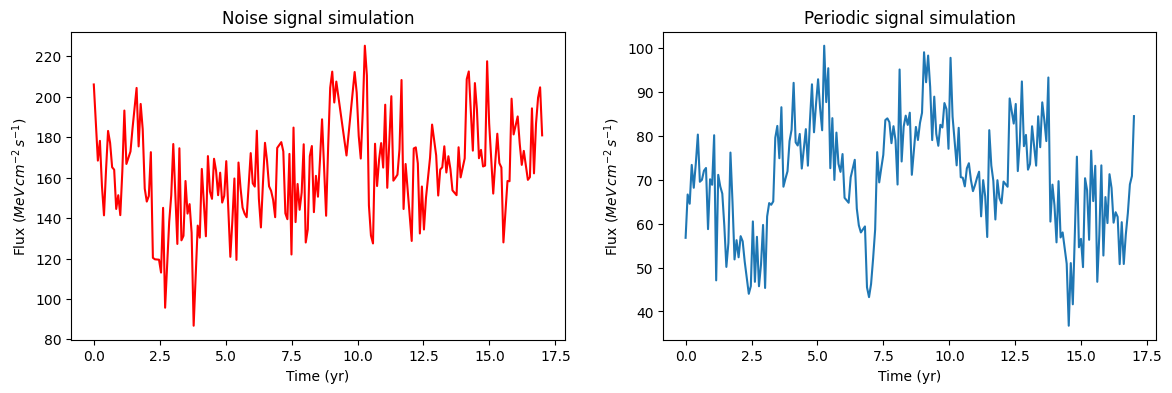

In [17]:
sim = LC_sim(17)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14,4))

time, flux = sim.noise()
ax1.plot(time, flux, c = 'r')
ax1.set_xlabel('Time (yr)')
ax1.set_ylabel(r'Flux $(MeV \, cm^{-2} \, s^{-1})$')
ax1.set_title('Noise signal simulation')

time, flux = sim.curve()
ax2.plot(time, flux)
ax2.set_xlabel('Time (yr)')
ax2.set_ylabel(r'Flux $(MeV \, cm^{-2} \, s^{-1})$')
ax2.set_title('Periodic signal simulation')

plt.plot()

Now, we must identify the features to choose for training the model, while taking care to avoid any data leakage. In order to avoid any change of units, since the simulated LCs are computed in different units from the units reported in the Fermi-LAT LCR (energy flux vs photon flux), every feature selected is adimensional. For the simulated LCs we perform the same analysis as for the raw curves from the sample and get:

- The ratio of the best-fit FTP period in the first half of the light curve versus the second half.
- The height of the primary periodogram peak relative to the local noise continuum.
- The ratio of the peak power recovered by the morphology-aware FTP versus the standard Lomb-Scargle periodogram.
- The amplitude of the oscillatory component relative to the residual noise.
- Autocorrelation coefficients of the isolated oscillatory component and the raw light curve, respectively, measuring cycle-to-cycle internal memory.





### Evaluation of the performance of the model

Model Evaluation and PerformanceModel performance is evaluated using a dedicated validation dataset, where oscillatory behavior is defined as the positive class. In this framework, a True Positive (TP) represents an oscillatory signal correctly identified by the classifier, whereas a False Positive (FP) occurs when a purely stochastic signal is incorrectly categorized as periodic. Conversely, noise-dominated signals are labeled as negative. Our primary metric for evaluation is Accuracy, defined as the ratio of correct predictions to the total number of samples:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
We monitor accuracy across both the training and validation sets to ensure the model generalizes well. While we expect higher performance on the training data, a slight decrease in validation accuracy is anticipated as the model encounters unseen signals. Furthermore, as the number of training samples increases, the model's predictive power typically improves, leading to higher convergence in the validation scores. This relationship is visually represented through a learning curve, which tracks the evolution of performance as a function of dataset size.

## References

<a name="ref1">[1]</a> A. Rico et al., «Singular spectrum analysis of Fermi-LAT blazar light curves: A systematic search for periodicity and trends in the time domain», A&A, vol. 697, p. A35, may 2025, doi: 10.1051/0004-6361/202452495.

<a name="ref1">[2]</a> J. Hoffman, J. Vanderplas, J. Hartman, y G. Bakos, «A Fast Template Periodogram for Detecting Non-sinusoidal Fixed-shape Signals in Irregularly Sampled Time Series», 7 de febrero de 2021, arXiv: arXiv:2101.12348. doi: 10.48550/arXiv.2101.12348.
